## 1. Installing Required Packages

In [ ]:
# =============================================================================
# Installing required packages
# =============================================================================
!pip install -U scikit-learn scikeras --quiet
!pip install statsmodels optuna tabulate xgboost scikeras --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 10.2 MB/s eta 0:00:00


## 2. Imports & Global Settings

In [ ]:
# Standard libraries
import sys
import os
import warnings
import random
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np   # Numerical operations
import pandas as pd  # Data manipulation and analysis

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Preprocessing & model selection
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (TimeSeriesSplit, GridSearchCV,
                                     RandomizedSearchCV)
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score)
from sklearn.inspection import permutation_importance
from sklearn.neural_network import MLPRegressor
from scipy.stats import randint, uniform

# XGBoost
import xgboost as xgb

# TensorFlow / Keras (LSTM)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, Flatten
from tensorflow.keras.optimizers import Adam

# SciKeras wrapper (scikit-learn API for Keras)
from scikeras.wrappers import KerasRegressor

# Optuna (Bayesian hyperparameter optimisation)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress verbose trial logs

# ── Global random seed (set once; reused throughout) ──────────────────────────
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print(f"Global random seed set to {RANDOM_SEED}")


Global random seed set to 42


## 3. Loading the Dataset

In [ ]:
# =============================================================================
# LOADING THE DATASET
# Dataset sources:
#   https://drive.google.com/file/d/1Z_KsoIumw-fvivVombIoWuRo0LOe2nCb/view?usp=sharing
#   https://drive.google.com/file/d/1aD1PXfwEEZ_F2lQgxuPfj-TVbxQ6NajK/view?usp=sharing
# =============================================================================

file_id      = "1c5KmcFD1TOsqASqzy0KiYo-7IzgBFuhk"   # Variable Set 2 dataset
download_url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv(download_url)

# Create a proper datetime index from year / month / day columns
df['Date'] = pd.to_datetime({
    'year':  df['YEAR'],
    'month': df['MO'],
    'day':   df['DY']
})
df = df.set_index('Date')

# Drop the raw date columns (now encoded in the index)
df = df.drop(columns=["YEAR", "MO", "DY"])

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())
print("\nColumns:", df.columns.tolist())


Dataset loaded successfully.
Shape: (4015, 14)

First 5 rows:


,WS10M_lag1,RH,MIN_TEMP,PREC,WD_sin,SURF_PRESSURE_DIFF,AVG_TEMP,WD_cos,RH_lag1,MONOSOON_SEASON_Southwest_Monsoon,MAX_TEMP,SL_PRESSURE_lag1,CLOUD_COVER,WS10M
Date,,,,,,,,,,,,,,
2013-01-03,4.25,86.26,23.42,13.42,0.439939,0.03,26.4,0.898028,86.19,0,28.38,1010.4,8.0,4.75
2013-01-04,4.75,86.31,22.93,8.79,0.424199,-0.03,25.1,0.905569,86.26,0,27.58,1011.0,8.0,5.74
2013-01-05,5.74,86.88,22.17,2.60,0.563526,-0.15,26.9,0.826098,86.31,0,26.16,1010.1,8.0,5.79
2013-01-06,5.79,88.09,23.47,1.65,0.460200,-0.03,27.3,0.887815,86.88,0,27.75,1007.5,7.0,4.52
2013-01-07,4.52,93.04,24.04,27.41,0.368125,-0.01,25.9,0.929776,88.09,0,26.70,1008.2,8.0,4.66



Columns: ['WS10M_lag1', 'RH', 'MIN_TEMP', 'PREC', 'WD_sin', 'SURF_PRESSURE_DIFF', 'AVG_TEMP', 'WD_cos', 'RH_lag1', 'MONOSOON_SEASON_Southwest_Monsoon', 'MAX_TEMP', 'SL_PRESSURE_lag1', 'CLOUD_COVER', 'WS10M']


## 4. Primary Train-Test Split (80/20, Time-Based)

In [ ]:
# =============================================================================
# Train-test split — first 80% for training, last 20% for testing.
# Temporal ordering is strictly preserved; no shuffling is applied.
# =============================================================================

X = df.drop(columns=['WS10M'])  # Feature matrix
y = df['WS10M']                 # Target: wind speed (m/s)

split_index = int(len(X) * 0.8)  # 80% training, 20% testing

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_test  = y.iloc[split_index:]

print(f"Total samples : {len(X)}")
print(f"Training set  : {X_train.shape}  (first {split_index} samples)")
print(f"Test set      : {X_test.shape}  (last {len(X) - split_index} samples)")
print(f"\nTrain period: {X_train.index[0].date()}  →  {X_train.index[-1].date()}")
print(f"Test period : {X_test.index[0].date()}  →  {X_test.index[-1].date()}")


Total samples : 4015
Training set  : (3212, 13)  (first 3212 samples)
Test set      : (803, 13)  (last 803 samples)

Train period: 2013-01-03  →  2021-10-19
Test period : 2021-10-20  →  2023-12-31


## 5. Shared Helper Functions

In [ ]:
# =============================================================================
# Helper functions used by all model sections below.
# Defined once here to avoid repetition.
# =============================================================================

def evaluate(y_true, y_pred, label=""):
    """Print and return evaluation metrics for the residual correction model."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"{label} MSE:  {mse:.4f}")
    print(f"{label} RMSE: {rmse:.4f}")
    print(f"{label} MAE:  {mae:.4f}")
    print(f"{label} MAPE: {mape:.2f}%")
    print(f"{label} R²:   {r2:.4f}")
    return mse, rmse, mae, mape, r2


def evaluate_performance(y_true, y_pred, set_name="Dataset"):
    """Evaluate and return metrics as a dictionary for the hybrid model."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"\n--- {set_name} Metrics ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.4f}%")
    print(f"R²:   {r2:.4f}")
    return {'RMSE': rmse, 'MSE': mse, 'MAE': mae, 'MAPE': mape, 'R²': r2}


## 6. XGBoost Primary Model (Optuna-Optimised Parameters)

In [ ]:
# =============================================================================
# XGBoost Primary Model
# Best parameters sourced from prior Optuna optimisation run.
# The model is fitted on X_train only; predictions over the full dataset are
# stored so residuals can be computed for the LSTM correction layer.
# =============================================================================

# Best Parameters: {'n_estimators': 300, 'max_depth': 6,
#   'learning_rate': 0.02017215364230889, 'min_child_weight': 5,
#   'gamma': 0.019237778052053844, 'subsample': 0.618408743715084}
Best_Parameters = {
    'n_estimators':     300,
    'max_depth':        6,
    'learning_rate':    0.02017215364230889,
    'gamma':            0.019237778052053844,
    'subsample':        0.618408743715084,
    'min_child_weight': 5
}

# Initialise XGBRegressor with optimal parameters
best_xgb = xgb.XGBRegressor(**Best_Parameters, random_state=RANDOM_SEED)

# Fit on training data only (test set remains unseen until evaluation)
best_xgb.fit(X_train, y_train)
print(f"XGBoost fitted. Parameters: {Best_Parameters}")

# ── Train / Test predictions ──────────────────────────────────────────────────
y_train_pred_xgb = best_xgb.predict(X_train)
y_test_pred_xgb  = best_xgb.predict(X_test)

# ── Evaluation metrics ────────────────────────────────────────────────────────
xgb_train_mse  = mean_squared_error(y_train, y_train_pred_xgb)
xgb_test_mse   = mean_squared_error(y_test,  y_test_pred_xgb)
xgb_train_mae  = mean_absolute_error(y_train, y_train_pred_xgb)
xgb_test_mae   = mean_absolute_error(y_test,  y_test_pred_xgb)
xgb_train_rmse = np.sqrt(xgb_train_mse)
xgb_test_rmse  = np.sqrt(xgb_test_mse)
xgb_train_mape = np.mean(np.abs((y_train - y_train_pred_xgb) / y_train)) * 100
xgb_test_mape  = np.mean(np.abs((y_test  - y_test_pred_xgb)  / y_test))  * 100
xgb_train_r2   = r2_score(y_train, y_train_pred_xgb)
xgb_test_r2    = r2_score(y_test,  y_test_pred_xgb)

print(f"\nTrain MSE:  {xgb_train_mse:.4f}  | Test MSE:  {xgb_test_mse:.4f}")
print(f"Train MAE:  {xgb_train_mae:.4f}  | Test MAE:  {xgb_test_mae:.4f}")
print(f"Train RMSE: {xgb_train_rmse:.4f} | Test RMSE: {xgb_test_rmse:.4f}")
print(f"Train MAPE: {xgb_train_mape:.4f}%| Test MAPE: {xgb_test_mape:.4f}%")
print(f"Train R²:   {xgb_train_r2:.4f}  | Test R²:   {xgb_test_r2:.4f}")

# ── Summary table (Plotly) ────────────────────────────────────────────────────
summary_df = pd.DataFrame({
    'Parameter/Metric': list(Best_Parameters.keys()) +
                        ['Train MSE', 'Test MSE', 'Train MAE', 'Test MAE',
                         'Train RMSE', 'Test RMSE', 'Train MAPE (%)',
                         'Test MAPE (%)', 'Train R²', 'Test R²'],
    'Value': list(Best_Parameters.values()) +
             [xgb_train_mse, xgb_test_mse, xgb_train_mae, xgb_test_mae,
              xgb_train_rmse, xgb_test_rmse, xgb_train_mape, xgb_test_mape,
              xgb_train_r2, xgb_test_r2]
})
summary_df['Value'] = summary_df['Value'].apply(lambda x: f"{x:.6f}")

fig_table = go.Figure(go.Table(
    header=dict(
        values=['<b>Parameter / Metric</b>', '<b>Value</b>'],
        fill_color='steelblue',
        font=dict(color='white', size=13),
        align='left'
    ),
    cells=dict(
        values=[summary_df['Parameter/Metric'], summary_df['Value']],
        fill_color=[['lightcyan' if i % 2 == 0 else 'white'
                     for i in range(len(summary_df))]],
        align='left'
    )
))
fig_table.update_layout(
    title="XGBoost Optimal Parameters & Model Performance Metrics",
    template="plotly_white", height=600
)
fig_table.show()


XGBoost fitted. Parameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.02017215364230889, 'gamma': 0.019237778052053844, 'subsample': 0.618408743715084, 'min_child_weight': 5}

Train MSE:  0.2103  | Test MSE:  0.5259
Train MAE:  0.3590  | Test MAE:  0.5495
Train RMSE: 0.4586 | Test RMSE: 0.7252
Train MAPE: 9.9187%| Test MAPE: 14.9222%
Train R²:   0.9165  | Test R²:   0.7819


## 7. Out-of-Fold XGBoost Residuals (Training Set)

In [ ]:
# =============================================================================
# OUT-OF-FOLD (OOF) XGBOOST RESIDUALS ON THE TRAINING SET
# -----------------------------------------------------------------------------
# WHAT THIS CELL DOES
#   For each TimeSeriesSplit fold, we fit a FRESH XGBoost model (same tuned
#   hyperparameters as `best_xgb`) using only the rows strictly before the
#   fold's validation window, then predict on that validation window only.
#   Every prediction produced this way is out-of-sample with respect to the
#   model that produced it -- exactly like the situation at deployment time.
#
# WHY NOT JUST REUSE `best_xgb` (the model fit on the whole training set)?
#   `best_xgb` has already seen every training row during fitting, so its
#   predictions on those same rows are in-sample and would recreate the
#   original leakage problem. OOF cross-validation is the standard way to
#   obtain leakage-free "training set" predictions from a model that must
#   also be fit on the full training set for later deployment.
#
# THE UNAVOIDABLE GAP
#   TimeSeriesSplit needs an initial block of data to train the very first
#   fold, so the earliest rows of the training set (before the first fold's
#   validation window begins) never appear in any validation fold and cannot
#   get a leakage-free OOF prediction. We leave these as NaN here and drop
#   them explicitly later -- filling them with an in-sample prediction would
#   silently reintroduce the leakage this cell exists to remove.
# =============================================================================

N_SPLITS_OOF = 5  # same fold count used later for CNN cross-validation
tscv_oof = TimeSeriesSplit(n_splits=N_SPLITS_OOF)

# Pre-allocate with NaN -- rows never selected as a validation fold (the
# initial training block) keep their NaN and are dropped further down.
oof_pred_train = np.full(shape=len(X_train), fill_value=np.nan)

print(f"Generating out-of-fold XGBoost predictions "
      f"({N_SPLITS_OOF}-fold TimeSeriesSplit) on {len(X_train)} training rows...\n")

for fold_i, (fold_train_idx, fold_val_idx) in enumerate(tscv_oof.split(X_train), start=1):
    # Fit a FRESH XGBoost (same tuned hyperparameters as best_xgb) using only
    # data strictly earlier than this fold's validation window.
    fold_model = xgb.XGBRegressor(**Best_Parameters, random_state=RANDOM_SEED)
    fold_model.fit(X_train.iloc[fold_train_idx], y_train.iloc[fold_train_idx])

    # Predict ONLY on the held-out fold -- genuinely out-of-sample for this model
    fold_val_pred = fold_model.predict(X_train.iloc[fold_val_idx])
    oof_pred_train[fold_val_idx] = fold_val_pred

    print(f"  Fold {fold_i}: fit on {len(fold_train_idx):>5} earlier rows -> "
          f"predicted {len(fold_val_idx):>5} held-out rows "
          f"(val idx {fold_val_idx[0]}:{fold_val_idx[-1]})")

n_missing = int(np.isnan(oof_pred_train).sum())
print(f"\nTraining rows with NO OOF prediction (initial block, dropped later): {n_missing}")
print(f"Training rows with a valid OOF prediction: {len(X_train) - n_missing} / {len(X_train)}")

# Out-of-fold residual = actual - OOF prediction (NaN where no OOF prediction exists)
oof_residual_train = y_train.values - oof_pred_train


Generating out-of-fold XGBoost predictions (5-fold TimeSeriesSplit) on 3212 training rows...

  Fold 1: fit on   537 earlier rows -> predicted   535 held-out rows (val idx 537:1071)
  Fold 2: fit on  1072 earlier rows -> predicted   535 held-out rows (val idx 1072:1606)
  Fold 3: fit on  1607 earlier rows -> predicted   535 held-out rows (val idx 1607:2141)
  Fold 4: fit on  2142 earlier rows -> predicted   535 held-out rows (val idx 2142:2676)
  Fold 5: fit on  2677 earlier rows -> predicted   535 held-out rows (val idx 2677:3211)

Training rows with NO OOF prediction (initial block, dropped later): 537
Training rows with a valid OOF prediction: 2675 / 3212


## 8. Combining OOF (Train) and Out-of-Sample (Test) Residuals

In [ ]:
# =============================================================================
# COMBINE OOF (TRAIN) + OUT-OF-SAMPLE (TEST) PREDICTIONS INTO ONE RESIDUAL SERIES
# -----------------------------------------------------------------------------
#   Train rows : the out-of-fold predictions computed in the cell above
#                (oof_pred_train). Each one is out-of-sample with respect to
#                the fold model that produced it.
#   Test rows  : predictions from `best_xgb`, the single model fit on the
#                FULL training set (already computed above as
#                y_test_pred_xgb). These were always genuinely out-of-sample
#                with respect to best_xgb, so nothing changes here.
#
# The resulting 'Residual' column is out-of-sample everywhere -- this is the
# target the CNN residual-correction model is actually trained and
# evaluated against, instead of the old in-sample train residuals.
# =============================================================================

# Predictions used downstream: OOF for train rows, out-of-sample for test rows
y_pred_full_xgb = np.concatenate([oof_pred_train, y_test_pred_xgb])

df['Pred_XGB_Optuna'] = y_pred_full_xgb
df['Residual']        = df['WS10M'] - df['Pred_XGB_Optuna']

# Kept ONLY for comparison/diagnostics -- this is the old in-sample prediction
# from the model fit on the full training set. It is NOT used to train the
# CNN; it lets the size of the leakage gap be inspected directly, e.g. by
# comparing 'Residual' against WS10M - Pred_XGB_Optuna_insample.
df['Pred_XGB_Optuna_insample'] = best_xgb.predict(X)

print("Predictions and OOF (train) / out-of-sample (test) residuals added to dataframe.")
print(f"NaN residuals (initial training block with no OOF fold coverage): "
      f"{int(df['Residual'].isna().sum())}")
print(df[['WS10M', 'Pred_XGB_Optuna', 'Residual']].head(10))
print(f"\nDataframe shape: {df.shape}")

# Backup the enriched dataframe -- this is the master reference for all hybrid models
df_backup = df.copy()

# -- Visualise actual vs predicted + residuals -------------------------------
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=("Actual vs Predicted Wind Speed (OOF train / out-of-sample test)",
                     "Residuals (OOF train / out-of-sample test)"),
    shared_xaxes=True,
    vertical_spacing=0.12
)
fig.add_trace(go.Scatter(
    x=df.index, y=df['WS10M'],
    mode='lines', name='Actual WS10M',
    line=dict(color='steelblue', width=1.5)
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=df.index, y=df['Pred_XGB_Optuna'],
    mode='lines', name='Predicted (OOF train / out-of-sample test)',
    line=dict(color='orange', width=1.5, dash='dot')
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=df.index, y=df['Residual'],
    mode='lines', name='Residual',
    line=dict(color='crimson', width=1)
), row=2, col=1)
fig.add_hline(y=0, line_dash="dash", line_color="black", row=2, col=1)

fig.update_layout(
    height=700, template="plotly_white",
    title="XGBoost -- OOF (train) / Out-of-Sample (test) Predictions & Residuals",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)
fig.update_yaxes(title_text="Wind Speed (m/s)", row=1, col=1)
fig.update_yaxes(title_text="Residual",         row=2, col=1)
fig.update_xaxes(title_text="Date",             row=2, col=1)
fig.show()

# Save XGBoost predictions to CSV
df.to_csv('XGB_Primary_Model_Prediction.csv', index=True)
print("\nSaved to 'XGB_Primary_Model_Prediction.csv'")


Predictions and OOF (train) / out-of-sample (test) residuals added to dataframe.
NaN residuals (initial training block with no OOF fold coverage): 537
            WS10M  Pred_XGB_Optuna  Residual
Date                                        
2013-01-03   4.75              NaN       NaN
2013-01-04   5.74              NaN       NaN
2013-01-05   5.79              NaN       NaN
2013-01-06   4.52              NaN       NaN
2013-01-07   4.66              NaN       NaN
2013-01-08   3.61              NaN       NaN
2013-01-09   4.19              NaN       NaN
2013-01-10   5.41              NaN       NaN
2013-01-11   5.95              NaN       NaN
2013-01-12   5.80              NaN       NaN

Dataframe shape: (4015, 17)



Saved to 'XGB_Primary_Model_Prediction.csv'


## 9. Residual Autocorrelation (ACF/PACF) Diagnostics

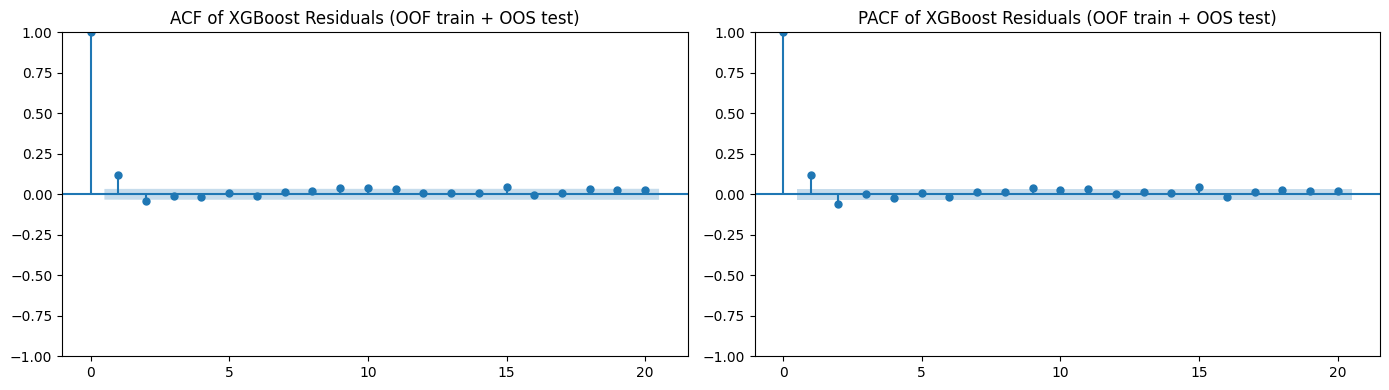

N = 3478 residuals | 95% significance threshold: |ACF| > 0.0332

Lag | ACF value | Significant?
  1 |    0.1170 |  <-- significant
  2 |   -0.0425 |  <-- significant
  3 |   -0.0110 |
  4 |   -0.0197 |
  5 |    0.0055 |
  6 |   -0.0109 |
  7 |    0.0126 |
  8 |    0.0211 |
  9 |    0.0419 |  <-- significant
 10 |    0.0376 |  <-- significant
 11 |    0.0340 |  <-- significant
 12 |    0.0072 |
 13 |    0.0100 |
 14 |    0.0087 |
 15 |    0.0444 |  <-- significant
 16 |   -0.0038 |
 17 |    0.0075 |
 18 |    0.0302 |
 19 |    0.0262 |
 20 |    0.0258 |

Statistically significant lags (95% level): [1, 2, 9, 10, 11, 15]

Ljung-Box test (H0: no autocorrelation up to the given lag):
      lb_stat     lb_pvalue
5   55.826496  8.823323e-11
10  69.389684  5.815016e-11
20  89.284626  9.884496e-11

(A p-value below 0.05 rejects H0 -- i.e. there IS significant autocorrelation up to that lag.)


In [ ]:
# =============================================================================
# RESIDUAL AUTOCORRELATION (ACF / PACF) DIAGNOSTICS
# -----------------------------------------------------------------------------
# WHAT THIS CELL DOES
#   Plots the autocorrelation (ACF) and partial autocorrelation (PACF) of the
#   OOF-train / OOS-test residual series, then flags which lags are
#   statistically significant using the standard large-sample white-noise
#   bound |ACF(k)| > 1.96/sqrt(N), and cross-checks with a Ljung-Box test.
#
# HOW TO READ IT
#   - ACF: correlation between the residual at time t and at time t-k.
#   - PACF: same, but with the effect of the intermediate lags removed --
#     useful for deciding how many lag features are actually independently
#     informative (e.g. if only lag 1 is significant in the PACF, adding a
#     lag-2 feature likely won't help beyond what lag-1 already captures).
#   - Shaded bands in the plots are the approximate 95% confidence interval
#     under the null hypothesis of no autocorrelation.
# =============================================================================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf as acf_fn
from statsmodels.stats.diagnostic import acorr_ljungbox

# Use only rows with a valid (non-NaN) residual -- excludes Fold 1's
# OOF-uncovered training block (see Section 7).
residual_series = df['Residual'].dropna()
N = len(residual_series)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residual_series, lags=20, ax=axes[0], alpha=0.05)
axes[0].set_title("ACF of XGBoost Residuals (OOF train + OOS test)")
plot_pacf(residual_series, lags=20, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title("PACF of XGBoost Residuals (OOF train + OOS test)")
plt.tight_layout()
plt.show()

# ── Identify statistically significant lags (ACF) ────────────────────────────
n_lags = 20
threshold = 1.959964 / np.sqrt(N)  # standard 95% approx. bound for white noise
acf_vals = acf_fn(residual_series, nlags=n_lags, fft=False)

print(f"N = {N} residuals | 95% significance threshold: |ACF| > {threshold:.4f}\n")
print("Lag | ACF value | Significant?")
significant_lags = []
for lag in range(1, n_lags + 1):
    is_sig = abs(acf_vals[lag]) > threshold
    marker = "  <-- significant" if is_sig else ""
    print(f"{lag:>3} | {acf_vals[lag]:>9.4f} |{marker}")
    if is_sig:
        significant_lags.append(lag)

print(f"\nStatistically significant lags (95% level): {significant_lags}")

# ── Ljung-Box test: are residuals jointly autocorrelated up to lag k? ───────
lb_test = acorr_ljungbox(residual_series, lags=[5, 10, 20], return_df=True)
print("\nLjung-Box test (H0: no autocorrelation up to the given lag):")
print(lb_test)
print("\n(A p-value below 0.05 rejects H0 -- i.e. there IS significant "
      "autocorrelation up to that lag.)")


## 10. Residual-Correction Feature Set

In [ ]:
# =============================================================================
# Feature set for LSTM residual correction model
# -----------------------------------------------------------------------------
# Adds two new engineered features: Residual_lag1, Residual_lag2 -- the
# previous 1 and 2 days' OOF (train) / out-of-sample (test) XGBoost
# residuals. The ACF/PACF diagnostics above (Section 9) are used to decide
# whether these lags carry real signal; the features are included here so
# the LSTM can exploit residual autocorrelation that the exogenous features
# alone cannot capture, since the LSTM otherwise sees the same information
# XGBoost already used.
#
# WHY THIS IS NOT LEAKAGE: at forecast time for day t, the actual wind speed
# (and hence residual) for day t-1 and t-2 has already been observed -- these
# are genuine past values, not information from the future or from the row
# being predicted itself.
#
# Train rows: restricted to those with a valid OUT-OF-FOLD residual (see
#   Section 7). The initial training block with no OOF coverage is dropped.
# Test rows: unchanged -- always genuinely out-of-sample.
# =============================================================================

df['Residual_lag1'] = df['Residual'].shift(1)
df['Residual_lag2'] = df['Residual'].shift(2)

# NOTE: df_backup was already snapshotted (df_backup = df.copy()) back in
# Section 8, BEFORE these two lag columns existed on df -- so df_backup is
# missing them unless we sync them across explicitly here. Every downstream
# section reads df_backup (not df) when saving the per-model CSV export via
# `df_backup[fnn_features + [...]]`, which would otherwise raise
# `KeyError: ['Residual_lag1', 'Residual_lag2'] not in index`.
df_backup['Residual_lag1'] = df['Residual_lag1']
df_backup['Residual_lag2'] = df['Residual_lag2']

# RESIDUAL CORRECTION MODEL
fnn_features = [
    'Residual_lag1', 'Residual_lag2'    # NEW: autoregressive residual features
]

X_res = df[fnn_features]  # Features for residual correction
y_res = df['Residual']    # Target: OOF (train) / out-of-sample (test) XGBoost residuals

# Same 80 / 20 temporal split index as the primary model
split_index_res = int(len(X_res) * 0.8)

X_train_res_full = X_res.iloc[:split_index_res]
y_train_res_full = y_res.iloc[:split_index_res]
X_test_res        = X_res.iloc[split_index_res:]
y_test_res         = y_res.iloc[split_index_res:]

# ── Drop rows with any NaN feature or target ─────────────────────────────────
# Two independent sources of NaN now exist:
#   1. Fold 1 of TimeSeriesSplit(n_splits=5) has no preceding validation
#      block, so its training rows were never given an OOF residual
#      (Section 7) -- this affects y_train_res_full AND, via the .shift()
#      above, the Residual_lag1 / Residual_lag2 columns of the rows right
#      after that gap.
#   2. The very first 1-2 rows of the entire series have no lag-1/lag-2
#      residual to look back on.
# Filling either with a synthetic value would fabricate information or
# quietly leak, so these rows are dropped instead. Test rows are expected to
# lose none (their lag features look back into the already-valid tail of the
# training period), but the same check is applied for correctness.
train_valid_mask = X_train_res_full.notna().all(axis=1) & y_train_res_full.notna()
test_valid_mask  = X_test_res.notna().all(axis=1)       & y_test_res.notna()

X_train_res = X_train_res_full.loc[train_valid_mask]
y_train_res = y_train_res_full.loc[train_valid_mask]
X_test_res  = X_test_res.loc[test_valid_mask]
y_test_res  = y_test_res.loc[test_valid_mask]

n_dropped_train = int((~train_valid_mask).sum())
n_dropped_test  = int((~test_valid_mask).sum())

print(f"LSTM residual correction -- training rows dropped (no OOF residual "
      f"and/or lag feature): {n_dropped_train}")
print(f"LSTM residual correction -- training samples used  : {X_train_res.shape[0]}")
print(f"LSTM residual correction -- test samples            : {X_test_res.shape[0]} "
      f"(dropped {n_dropped_test} rows with a missing lag feature)")
print(f"Number of input features                             : {X_train_res.shape[1]}")


LSTM residual correction -- training rows dropped (no OOF residual and/or lag feature): 539
LSTM residual correction -- training samples used  : 2673
LSTM residual correction -- test samples            : 803 (dropped 0 rows with a missing lag feature)
Number of input features                             : 2


## 11. LSTM Residual Correction — Grid Search Hyperparameter Optimisation

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best Parameters (Grid Search):
{'batch_size': 32, 'epochs': 50, 'model__dropout_rate': 0.3, 'model__optimizer': 'rmsprop', 'model__units': 32}

--- Grid Search LSTM Residual Model Evaluation ---
Train (LSTM Grid Search) MSE:  0.5118
Train (LSTM Grid Search) RMSE: 0.7154
Train (LSTM Grid Search) MAE:  0.5474
Train (LSTM Grid Search) MAPE: 163.47%
Train (LSTM Grid Search) R²:   0.0190
Test  (LSTM Grid Search) MSE:  0.5180
Test  (LSTM Grid Search) RMSE: 0.7197
Test  (LSTM Grid Search) MAE:  0.5434
Test  (LSTM Grid Search) MAPE: 143.05%
Test  (LSTM Grid Search) R²:   0.0148


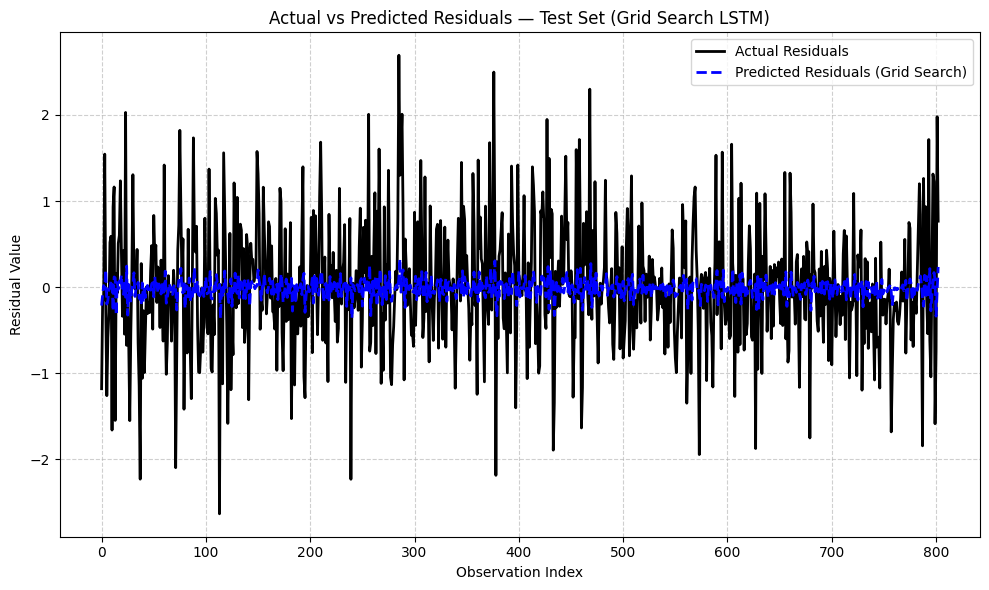

Full-dataset residual predictions: 3476 / 4015 rows (NaN elsewhere -- missing lag feature(s))

=== Hybrid XGB-LSTM (Grid Search) Performance on WS10M ===
(Train metrics computed on 2673 rows -- initial OOF-uncovered block excluded)

--- Train Metrics ---
RMSE: 0.7154
MSE:  0.5118
MAE:  0.5474
MAPE: 15.2854%
R²:   0.7969

--- Test Metrics ---
RMSE: 0.7197
MSE:  0.5180
MAE:  0.5434
MAPE: 14.6395%
R²:   0.7852


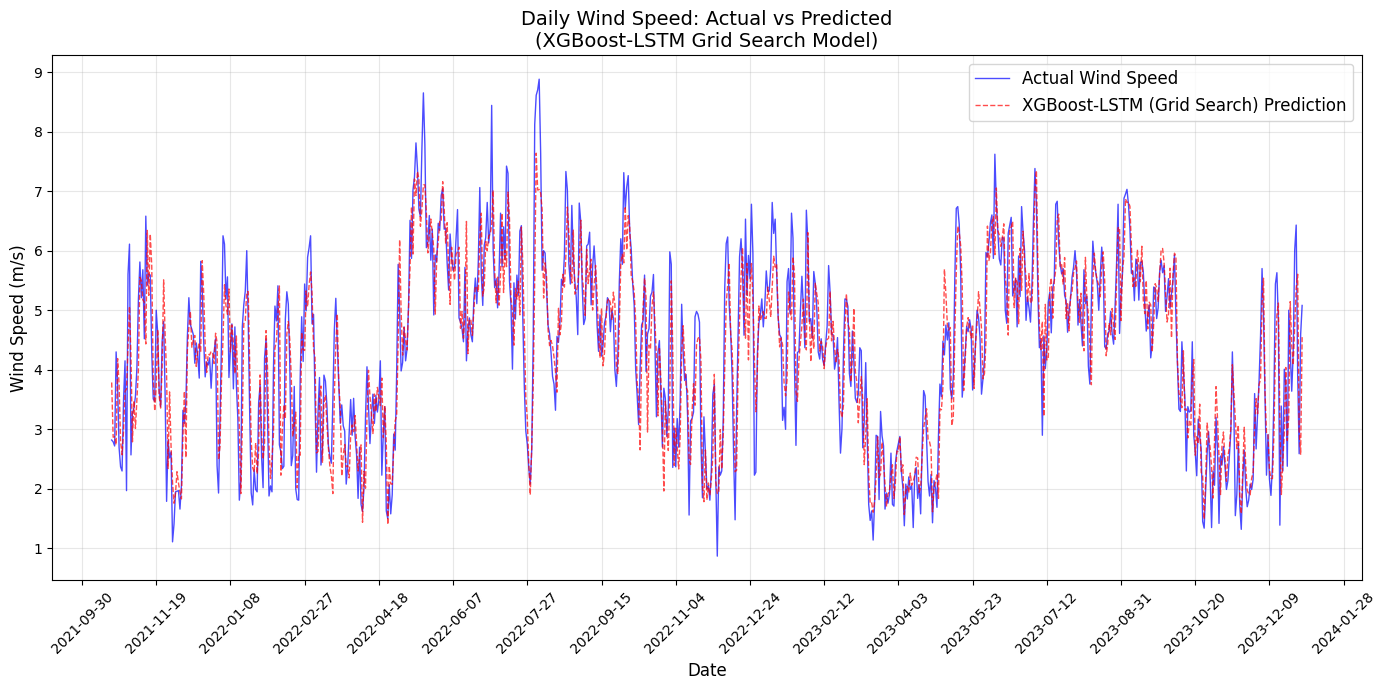

Saved to 'xgb_lstm_df_grid.csv'


In [ ]:
# =============================================================================
# Section 2 — Grid Search LSTM
# Exhaustive grid search over the defined parameter grid.
# TimeSeriesSplit (5 folds) is applied exclusively on the training data.
# Scaling is fit on training data only to prevent data leakage.
#
# FIX vs original code:
#   - Replaced cv=3 (standard K-Fold) with TimeSeriesSplit(n_splits=5)
#     to respect temporal ordering during cross-validation.
#   - Removed mid-notebook CSV reload which would have broken the pipeline
#     and required a separate file to exist on disk.
#   - All data is sourced from in-memory objects (X_train_res, y_train_res).
# =============================================================================

# ── Scaling (fit on training data only — no leakage) ─────────────────────────
scaler_grid     = StandardScaler()
X_train_sc_grid = scaler_grid.fit_transform(X_train_res)
X_test_sc_grid  = scaler_grid.transform(X_test_res)

# ── Reshape to LSTM format: (samples, timesteps=1, features) ─────────────────
X_train_lstm_grid = np.expand_dims(X_train_sc_grid, axis=1)
X_test_lstm_grid  = np.expand_dims(X_test_sc_grid,  axis=1)

# ── LSTM model builder (required by KerasRegressor) ──────────────────────────
def build_lstm_grid(units=64, dropout_rate=0.2, optimizer='adam'):
    """Builds and compiles an LSTM model for use in GridSearchCV."""
    n_features = X_train_lstm_grid.shape[2]
    mdl = Sequential([
        LSTM(units, activation='tanh', return_sequences=False,
             input_shape=(1, n_features)),
        Dropout(dropout_rate),
        Dense(1)
    ])
    mdl.compile(optimizer=optimizer, loss='mse')
    return mdl

# ── Wrap Keras model for scikit-learn API ─────────────────────────────────────
regressor_grid = KerasRegressor(
    model=build_lstm_grid, verbose=0, random_state=RANDOM_SEED
)

# ── Parameter grid ────────────────────────────────────────────────────────────
param_grid = {
    "model__units":        [32, 64, 128],
    "model__dropout_rate": [0.1, 0.2, 0.3],
    "model__optimizer":    ['adam', 'rmsprop'],
    "batch_size":          [16, 32],
    "epochs":              [50, 100]
}

# ── Time series cross-validation (training data only) ────────────────────────
tscv_grid = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=regressor_grid,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=tscv_grid,           # TimeSeriesSplit preserves temporal ordering
    verbose=2,
    n_jobs=-1
)

# Fit grid search on training data only
grid_search.fit(X_train_lstm_grid, y_train_res.values.flatten())

best_model_grid = grid_search.best_estimator_
print("\nBest Parameters (Grid Search):")
print(grid_search.best_params_)

# ── Residual model evaluation ─────────────────────────────────────────────────
y_train_pred_grid = best_model_grid.predict(X_train_lstm_grid).flatten()
y_test_pred_grid  = best_model_grid.predict(X_test_lstm_grid).flatten()

print("\n--- Grid Search LSTM Residual Model Evaluation ---")
evaluate(y_train_res.values, y_train_pred_grid, label="Train (LSTM Grid Search)")
evaluate(y_test_res.values,  y_test_pred_grid,  label="Test  (LSTM Grid Search)")

# Plot residual predictions on test set
plt.figure(figsize=(10, 6))
plt.plot(y_test_res.values, label='Actual Residuals',   color='black', linewidth=2)
plt.plot(y_test_pred_grid,  label='Predicted Residuals (Grid Search)',
         color='blue', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Residuals — Test Set (Grid Search LSTM)')
plt.xlabel('Observation Index')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Predict residuals on the FULL dataset ────────────────────────────────────
# NOTE: X_res (unlike X_train_res/X_test_res) is NOT pre-filtered for NaNs --
# it still contains the rows Section 10 dropped (Fold 1's OOF-uncovered
# training block, plus the first 1-2 rows with no Residual_lag1/lag2 to look
# back on). The LSTM can't handle NaN input, so we predict only on the rows
# where every feature is valid, and leave the rest as NaN -- consistent with
# 'Pred_XGB_Optuna' already being NaN for those same rows.
full_valid_mask = X_res.notna().all(axis=1)
X_full_sc_valid   = scaler_grid.transform(X_res.loc[full_valid_mask])
X_full_lstm_valid = np.expand_dims(X_full_sc_valid, axis=1)

predicted_residuals_lstm_grid_arr = np.full(len(X_res), np.nan)
predicted_residuals_lstm_grid_arr[full_valid_mask.values] = best_model_grid.predict(X_full_lstm_valid).flatten()
print(f"Full-dataset residual predictions: {int(full_valid_mask.sum())} / "
      f"{len(X_res)} rows (NaN elsewhere -- missing lag feature(s))")

df_backup['predicted_residuals_lstm_grid'] = predicted_residuals_lstm_grid_arr

# ── Hybrid prediction: XGB + LSTM residual correction ────────────────────────
df_backup['XGB_LSTM_grid'] = (df_backup['Pred_XGB_Optuna'] +
                               df_backup['predicted_residuals_lstm_grid'])

# ── Hybrid model train / test performance ────────────────────────────────────
# NOTE: df_backup['XGB_LSTM_grid'] is NaN for the initial training block that has no
# OOF residual (Sections 7 & 9) -- Pred_XGB_Optuna is NaN there, so those
# rows must be dropped before computing metrics, otherwise mean_squared_error
# etc. would raise or silently propagate NaN. Test rows are unaffected (they
# were always out-of-sample).
train_df_grid = df_backup.iloc[:split_index_res].copy()
train_df_grid = train_df_grid.dropna(subset=['XGB_LSTM_grid'])
test_df_grid  = df_backup.iloc[split_index_res:].copy()

print("\n=== Hybrid XGB-LSTM (Grid Search) Performance on WS10M ===")
print(f"(Train metrics computed on {len(train_df_grid)} rows -- initial "
      f"OOF-uncovered block excluded)")
train_metrics_grid = evaluate_performance(
    train_df_grid['WS10M'], train_df_grid['XGB_LSTM_grid'], set_name="Train")
test_metrics_grid  = evaluate_performance(
    test_df_grid['WS10M'],  test_df_grid['XGB_LSTM_grid'],  set_name="Test")

# ── Visualise test-set hybrid predictions ────────────────────────────────────
test_df_grid.index = pd.to_datetime(test_df_grid.index)
plt.figure(figsize=(14, 7))
plt.plot(test_df_grid.index, test_df_grid['WS10M'],
         label='Actual Wind Speed', color='blue', alpha=0.7, linewidth=1)
plt.plot(test_df_grid.index, test_df_grid['XGB_LSTM_grid'],
         label='XGBoost-LSTM (Grid Search) Prediction',
         color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.title('Daily Wind Speed: Actual vs Predicted\n(XGBoost-LSTM Grid Search Model)',
          fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save results to CSV
xgb_lstm_df_grid = df_backup[fnn_features + ['WS10M', 'XGB_LSTM_grid']]
xgb_lstm_df_grid.to_csv('xgb_lstm_df_grid.csv', index=True)
print("Saved to 'xgb_lstm_df_grid.csv'")


## 12. Shared Cross-Conformal Prediction-Interval Engine

In [ ]:
# =============================================================================
# SHARED CROSS-CONFORMAL ENGINE  (run this cell ONCE, before any model cell)
# -----------------------------------------------------------------------------
# FIXES vs. the original Section 14 code:
#
#   BUG 1 (fatal, stopped everything downstream of it):
#     `y_actual_train_full` / `xgb_pred_train_full` were sliced POSITIONALLY
#     from df_backup (length = split_index_res, i.e. the FULL, un-filtered
#     80% training block), while `X_train_res` / `y_train_res` had already
#     been filtered to drop NaN rows (the initial OOF-uncovered block, plus
#     the first 1-2 rows with no lag feature). Those two arrays are therefore
#     SHORTER, so `assert len(y_actual_train_full) == len(X_train_res)`
#     raised an AssertionError immediately -- before even the standalone XGB
#     calibration cell (which doesn't depend on the buggy variables) could
#     run. Even without the assert, feeding same-length-required arrays that
#     are actually misaligned would have silently paired each validation
#     fold's predictions with the WRONG actual/base-XGB rows.
#     FIX: `get_hybrid_train_calibration_arrays()` below re-derives the
#     residual-model features straight from df_backup and re-selects the
#     matching actual/base-XGB rows using `df_backup.loc[X_train_res.index]`
#     -- i.e. by DATE INDEX, not by position -- so alignment is guaranteed
#     regardless of how many rows were dropped upstream.
#
#   BUG 2 (fragility): the six calibration cells were one monolithic block
#     sharing global variable names with the model-training sections earlier
#     in the notebook, so one failing model (e.g. FNN not yet trained) broke
#     the whole six-way pd.concat and the comparison table.
#     FIX: every model below is a fully independent, try/except-wrapped cell
#     that only reads df_backup + its own tuned hyperparameters. Run them in
#     any order; any one can fail without affecting the others.
# =============================================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.neural_network import MLPRegressor

CONFIDENCE_LEVELS = {'90%': 0.10, '95%': 0.05}


def get_hybrid_train_calibration_arrays(df_backup, split_index_res,
                                         feature_cols=('Residual_lag1', 'Residual_lag2')):
    """Self-contained: rebuilds the residual-model calibration features
    directly from df_backup, then aligns the matching actual WS10M and fixed
    XGBoost predictions by DATE INDEX (not position) -- this is the fix for
    BUG 1 above."""
    feats = list(feature_cols)
    X_res_full = df_backup[feats].iloc[:split_index_res]
    y_res_full = df_backup['Residual'].iloc[:split_index_res]
    valid_mask = X_res_full.notna().all(axis=1) & y_res_full.notna()

    X_train_res = X_res_full.loc[valid_mask]
    y_train_res = y_res_full.loc[valid_mask]
    y_actual_aligned = df_backup.loc[X_train_res.index, 'WS10M']
    xgb_pred_aligned  = df_backup.loc[X_train_res.index, 'Pred_XGB_Optuna']

    assert len(X_train_res) == len(y_train_res) == len(y_actual_aligned) == len(xgb_pred_aligned), \
        "Index misalignment while rebuilding hybrid calibration arrays -- please check df_backup."
    return X_train_res, y_train_res, y_actual_aligned, xgb_pred_aligned


def get_hybrid_test_point_forecast(df_backup, split_index_res, hybrid_col):
    """Pulls the already-computed test-set hybrid forecast (fixed XGB + tuned
    residual model) straight from df_backup, drops any NaN rows, and returns
    it aligned with the matching actual WS10M values."""
    y_pred_test = df_backup[hybrid_col].iloc[split_index_res:].dropna()
    y_actual_test = df_backup.loc[y_pred_test.index, 'WS10M']
    return y_actual_test, y_pred_test


def cross_conformal_pooled_errors(X_arr, y_fold_target_arr, y_actual_arr,
                                   base_pred_arr, fold_predict_fn,
                                   n_splits=5, variant_label="",
                                   is_residual_model=True):
    """Pools out-of-fold |actual - forecast| across a 5-fold TimeSeriesSplit.
    Unchanged core logic -- correctness now only requires its four array
    arguments to already be the same length and positionally aligned, which
    the two helpers above guarantee."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    pooled_abs_residuals = []
    fold_records = []

    for fold_i, (train_idx, val_idx) in enumerate(tscv.split(X_arr), start=1):
        X_t, X_v = X_arr[train_idx], X_arr[val_idx]
        y_t      = y_fold_target_arr[train_idx]

        pred_val = fold_predict_fn(X_t, y_t, X_v)

        if is_residual_model:
            forecast_val = base_pred_arr[val_idx] + pred_val
        else:
            forecast_val = pred_val

        actual_val = y_actual_arr[val_idx]
        abs_res = np.abs(actual_val - forecast_val)
        pooled_abs_residuals.extend(abs_res.tolist())

        fold_records.append({
            'Variant': variant_label, 'Fold': fold_i, 'Val_size': len(val_idx),
            'Mean_abs_forecast_error': abs_res.mean(),
            'Median_abs_forecast_error': np.median(abs_res)
        })
        print(f"[{variant_label}] Fold {fold_i}/{n_splits} "
              f"(val size={len(val_idx):4d}) - mean |forecast error| = {abs_res.mean():.4f}")

    return np.array(pooled_abs_residuals), pd.DataFrame(fold_records)


def conformal_quantile(abs_residuals, alpha=0.05):
    """Finite-sample-corrected split-conformal quantile. Guarantees marginal
    coverage of at least (1 - alpha) under exchangeability."""
    n = len(abs_residuals)
    q_level = min(np.ceil((n + 1) * (1 - alpha)) / n, 1.0)
    return np.quantile(abs_residuals, q_level, method='higher')


def evaluate_prediction_interval(y_true, y_pred, q):
    """Empirical coverage (%) and average interval width on the test set."""
    lower = y_pred - q
    upper = y_pred + q
    covered = (y_true >= lower) & (y_true <= upper)
    return lower, upper, covered.mean() * 100, (upper - lower).mean()


def build_pi_summary(variant_name, pooled_abs_residuals, y_actual_test, y_pred_test):
    """Builds the 90%/95% prediction-interval rows for one model.
    Returns (summary_df, bounds_dict) where bounds_dict['95%'] = (lower, upper)."""
    rows, bounds = [], {}
    for level_name, alpha in CONFIDENCE_LEVELS.items():
        q = conformal_quantile(pooled_abs_residuals, alpha=alpha)
        lower, upper, coverage, width = evaluate_prediction_interval(
            y_actual_test.values, y_pred_test.values, q)
        bounds[level_name] = (lower, upper)
        rows.append({
            'Model': variant_name, 'Confidence Level': level_name,
            'Calibration n': len(pooled_abs_residuals),
            'Margin (q, m/s)': round(q, 4),
            'Empirical Coverage (%)': round(coverage, 2),
            'Mean Interval Width (m/s)': round(width, 4)
        })
    return pd.DataFrame(rows), bounds


# ── Fold-level model factories (rebuild each already-tuned architecture per fold) ──

def build_fold_cnn(n_features, filters, dropout_rate, learning_rate):
    mdl = Sequential([
        Conv1D(filters=filters, kernel_size=1, activation='relu', input_shape=(1, n_features)),
        Flatten(), Dropout(dropout_rate), Dense(50, activation='relu'), Dense(1)
    ])
    mdl.compile(loss='mse', optimizer=Adam(learning_rate=learning_rate))
    return mdl


def build_fold_lstm_grid(n_features, units, dropout_rate, optimizer):
    mdl = Sequential([
        LSTM(units, activation='tanh', return_sequences=False, input_shape=(1, n_features)),
        Dropout(dropout_rate), Dense(1)
    ])
    mdl.compile(optimizer=optimizer, loss='mse')
    return mdl


def build_fold_lstm_adam(n_features, units, dropout_rate, learning_rate):
    mdl = Sequential([
        LSTM(units=units, input_shape=(1, n_features)),
        Dropout(dropout_rate), Dense(1)
    ])
    mdl.compile(loss='mse', optimizer=Adam(learning_rate=learning_rate))
    return mdl


def make_keras_fold_fn(model_builder, build_kwargs, batch_size, epochs, random_seed=42):
    """Wraps a Keras model builder into a fold_predict_fn (CNN / LSTM variants)."""
    def _fn(X_t, y_t, X_v):
        fold_scaler = StandardScaler()
        X_t_sc = fold_scaler.fit_transform(X_t)
        X_v_sc = fold_scaler.transform(X_v)
        X_t_3d = np.expand_dims(X_t_sc, axis=1)
        X_v_3d = np.expand_dims(X_v_sc, axis=1)
        n_features = X_t_3d.shape[2]
        tf.random.set_seed(random_seed)
        fold_model = model_builder(n_features, **build_kwargs)
        fold_model.fit(X_t_3d, y_t, epochs=epochs, batch_size=batch_size, verbose=0, shuffle=False)
        return fold_model.predict(X_v_3d, verbose=0).flatten()
    return _fn


def make_mlp_fold_fn(mlp_kwargs, random_seed=42):
    """Wraps MLPRegressor into a fold_predict_fn (FNN variant)."""
    def _fn(X_t, y_t, X_v):
        fold_scaler = StandardScaler()
        X_t_sc = fold_scaler.fit_transform(X_t)
        X_v_sc = fold_scaler.transform(X_v)
        fold_model = MLPRegressor(random_state=random_seed, **mlp_kwargs)
        fold_model.fit(X_t_sc, y_t)
        return fold_model.predict(X_v_sc)
    return _fn


def make_xgb_standalone_fold_fn(xgb_params, random_seed=42):
    """Wraps XGBRegressor into a fold_predict_fn (standalone XGB Optuna variant)."""
    def _fn(X_t, y_t, X_v):
        fold_model = xgb.XGBRegressor(**xgb_params, random_state=random_seed)
        fold_model.fit(X_t, y_t)
        return fold_model.predict(X_v)
    return _fn


print("Shared cross-conformal engine (fixed, index-aligned) loaded.")


Shared cross-conformal engine (fixed, index-aligned) loaded.


## 13. Prediction Interval — XGB-LSTM (Grid Search)

Addresses reviewer comment: *"The authors should obtain prediction intervals for the best-performing model to quantify the associated forecast uncertainty."* Cross-conformal calibration on the XGB-LSTM (Grid Search) hybrid model.

In [ ]:
# =============================================================================
# MODEL 3 / 6 — Prediction Interval: XGB-LSTM (Grid Search)
# -----------------------------------------------------------------------------
# Independent cell. Requires:
#   df_backup (with 'Residual_lag1', 'Residual_lag2', 'Pred_XGB_Optuna',
#              'Residual', and the already-computed 'XGB_LSTM_grid' column)
#   split_index_res, grid_search (fitted GridSearchCV object), RANDOM_SEED
# Run the ENGINE cell above once first. This cell does not read or write any
# variable used by the other five model cells.
# =============================================================================
try:
    X_train_res_grid, y_train_res_grid, y_actual_train_grid, xgb_pred_train_grid = \
        get_hybrid_train_calibration_arrays(df_backup, split_index_res)

    gs_best = grid_search.best_params_
    grid_build_kwargs = {
        'units':        gs_best['model__units'],
        'dropout_rate': gs_best['model__dropout_rate'],
        'optimizer':    gs_best['model__optimizer']
    }
    grid_fold_fn = make_keras_fold_fn(
        model_builder = build_fold_lstm_grid,
        build_kwargs  = grid_build_kwargs,
        batch_size    = gs_best['batch_size'],
        epochs        = gs_best['epochs'],
        random_seed   = RANDOM_SEED
    )

    pooled_residuals_grid, fold_summary_grid = cross_conformal_pooled_errors(
        X_arr              = X_train_res_grid.values,
        y_fold_target_arr  = y_train_res_grid.values,
        y_actual_arr       = y_actual_train_grid.values,
        base_pred_arr      = xgb_pred_train_grid.values,
        fold_predict_fn    = grid_fold_fn,
        n_splits           = 5,
        variant_label       = "XGB-LSTM (Grid Search)",
        is_residual_model  = True
    )
    print(f"\nPooled calibration residuals (XGB-LSTM Grid Search): n = {len(pooled_residuals_grid)}")

    y_actual_test_grid, y_pred_test_grid = get_hybrid_test_point_forecast(
        df_backup, split_index_res, 'XGB_LSTM_grid')

    pi_summary_grid, pi_bounds_grid = build_pi_summary(
        "XGB-LSTM (Grid Search)", pooled_residuals_grid, y_actual_test_grid, y_pred_test_grid)

    print("\n=== Prediction Interval — XGB-LSTM (Grid Search) ===")
    print(pi_summary_grid.to_string(index=False))
    pi_summary_grid.to_csv('pi_summary_xgb_lstm_grid.csv', index=False)
    print("Saved to 'pi_summary_xgb_lstm_grid.csv'")

except Exception as e:
    print(f"\n[MODEL 3 -- XGB-LSTM Grid Search] PI cell FAILED: {type(e).__name__}: {e}")
    print("(Make sure the LSTM Grid Search training section has been run so that "
          "'grid_search' and df_backup['XGB_LSTM_grid'] exist. "
          "The other five model cells are unaffected.)")
    pi_summary_grid, pi_bounds_grid = None, None


[XGB-LSTM (Grid Search)] Fold 1/5 (val size= 445) - mean |forecast error| = 0.5353
[XGB-LSTM (Grid Search)] Fold 2/5 (val size= 445) - mean |forecast error| = 0.5982
[XGB-LSTM (Grid Search)] Fold 3/5 (val size= 445) - mean |forecast error| = 0.5236
[XGB-LSTM (Grid Search)] Fold 4/5 (val size= 445) - mean |forecast error| = 0.5593
[XGB-LSTM (Grid Search)] Fold 5/5 (val size= 445) - mean |forecast error| = 0.5519

Pooled calibration residuals (XGB-LSTM Grid Search): n = 2225

=== Prediction Interval — XGB-LSTM (Grid Search) ===
                 Model Confidence Level  Calibration n  Margin (q, m/s)  Empirical Coverage (%)  Mean Interval Width (m/s)
XGB-LSTM (Grid Search)              90%           2225           1.1633                   89.66                     2.3267
XGB-LSTM (Grid Search)              95%           2225           1.4602                   94.15                     2.9204
Saved to 'pi_summary_xgb_lstm_grid.csv'
